# Étape 1 : Extraction des Flux RSS

In [3]:
# %pip install feedparser

     ---------------------------------------- 81.5/81.5 KB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Using legacy 'setup.py install' for sgmllib3k, since package 'wheel' is not installed.
  Running setup.py install for sgmllib3k: started
  Running setup.py install for sgmllib3k: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\mayom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


In [22]:
import feedparser
url_alerte = "https://www.cert.ssi.gouv.fr/alerte/feed/"
rss_alerte_feed = feedparser.parse(url_alerte)
for entry in rss_alerte_feed.entries:
    print("Titre :", entry.title)
    print("Description:", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)

url_avis = "https://www.cert.ssi.gouv.fr/avis/feed/"
rss_avis_feed = feedparser.parse(url_avis)
for entry in rss_avis_feed.entries:
    print("Titre :", entry.title)
    print("Description:", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)


Titre : [MàJ] Vulnérabilité dans Zimbra Collaboration Suite (17 juillet 2023)
Description: \[Mise à jour du 26 juillet 2023\] Publication du correctif de sécurité par l'éditeur Le 26 juillet 2023, l'éditeur a publié un correctif de sécurité \[1\] pour cette vulnérabilité immatriculée CVE-2023-37580. Il est donc fortement recommandé de déployer le correctif P41 pour toutes les versions...
Lien : https://www.cert.ssi.gouv.fr/alerte/CERTFR-2023-ALE-007/
Date : Mon, 17 Jul 2023 00:00:00 +0000
Titre : [MàJ] Vulnérabilité dans Citrix NetScaler ADC et NetScaler Gateway (19 juillet 2023)
Description: Le 18 juillet 2023, Citrix a publié un avis de sécurité concernant plusieurs vulnérabilités. La plus critique, dont l'identifiant CVE est CVE-2023-3519, permet à un attaquant non authentifié d'exécuter du code arbitraire à distance. L'équipement est vulnérable s'il est configuré en tant que...
Lien : https://www.cert.ssi.gouv.fr/alerte/CERTFR-2023-ALE-008/
Date : Wed, 19 Jul 2023 00:00:00 +0000
Ti

# Étape 2 : Extraction des CVE

In [96]:
from datetime import datetime
import requests
import re


cve_list_avis = []

# liste de dictionnaire pour le dataframe
list_cve = []
#url = "https://www.cert.ssi.gouv.fr/alerte/CERTFR-2024-ALE-001/json/"
for entry in rss_avis_feed.entries:
    link_array = entry.link.split("/")
    # example split :
    #['https:', '', 'www.cert.ssi.gouv.fr', 'avis', 'CERTFR-2026-AVI-0701', '']
    bulletin_name = link_array[4]
    url = "https://www.cert.ssi.gouv.fr/avis/" + bulletin_name +"/json/"
    #print(url)

    response = requests.get(url)
    data = response.json()
    for cve_item in data.get("cves", []):
            cve_id = cve_item.get("name")

            cve_data = {
                "ID ANSSI": bulletin_name,
                "Titre ANSSI": data.get("title"),
                "Type": "Avis",
                "Date": data.get('revisions')[0]['revision_date'],
                "CVE": cve_id,
                "CVSS": None,
                "Base Severity": None,
                "CWE": None,
                "EPSS": None,
                "Lien": cve_item.get("url"),
                "Description": data.get("description"),
                "Editeur": None,
                "Produit": None,
                "Versions affectées": None
            }
            list_cve.append(cve_data)


    #Extraction des CVE reference dans la clé cves du dict data
    ref_cves=list(data["cves"])
    #attention il s’agit d’une liste des dictionnaires avec name et url comme clés
    # print( "CVE référencés ", ref_cves)
    # Extraction des CVE avec une regex
    cve_pattern = (r"CVE-\d"
                   r""
                   r"{4}-\d{4,7}")
    cve_list_avis.append(list(set(re.findall(cve_pattern, str(data)))))


cve_list_alert = []
for entry in rss_alerte_feed.entries:
    link_array = entry.link.split("/")
    # example split :
    #['https:', '', 'www.cert.ssi.gouv.fr', 'avis', 'CERTFR-2026-AVI-0701', '']
    bulletin_name = link_array[4]
    url = "https://www.cert.ssi.gouv.fr/alerte/" + bulletin_name +"/json/"
    # print(url)

    response = requests.get(url)
    data = response.json()
    for cve_item in data.get("cves", []):
            cve_id = cve_item.get("name")

            cve_data = {
                "ID ANSSI": data.get("reference"),
                "Titre ANSSI": data.get("title"),
                "Type": "Alerte",
                "Date": data.get('revisions')[0]['revision_date'],
                "CVE": cve_id,
                "CVSS": None,
                "Base Severity": None,
                "CWE": None,
                "EPSS": None,
                "Lien": cve_item.get("url"),
                "Description": data.get("description"),
                "Editeur": None,        #
                "Produit": None,
                "Versions affectées": None
            }
            list_cve.append(cve_data)
    #Extraction des CVE reference dans la clé cves du dict data
    ref_cves=list(data["cves"])
    #attention il s’agit d’une liste des dictionnaires avec name et url comme clés
    # print( "CVE référencés ", ref_cves)
    # Extraction des CVE avec une regex
    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    cve_list_alert.append(list(set(re.findall(cve_pattern, str(data)))))

print(list_cve)


[{'ID ANSSI': 'CERTFR-2026-AVI-0699', 'Titre ANSSI': 'Vulnérabilité dans Cisco Catalyst SD-WAN', 'Type': 'Avis', 'Date': '2026-06-05T00:00:00.000000', 'CVE': 'CVE-2026-20245', 'CVSS': None, 'Base Severity': None, 'CWE': None, 'EPSS': None, 'Lien': 'https://www.cve.org/CVERecord?id=CVE-2026-20245', 'Description': None, 'Editeur': None, 'Produit': None, 'Versions affectées': None}, {'ID ANSSI': 'CERTFR-2026-AVI-0711', 'Titre ANSSI': 'Multiples vulnérabilités dans les VPN Check Point', 'Type': 'Avis', 'Date': '2026-06-09T00:00:00.000000', 'CVE': 'CVE-2026-50752', 'CVSS': None, 'Base Severity': None, 'CWE': None, 'EPSS': None, 'Lien': 'https://www.cve.org/CVERecord?id=CVE-2026-50752', 'Description': None, 'Editeur': None, 'Produit': None, 'Versions affectées': None}, {'ID ANSSI': 'CERTFR-2026-AVI-0711', 'Titre ANSSI': 'Multiples vulnérabilités dans les VPN Check Point', 'Type': 'Avis', 'Date': '2026-06-09T00:00:00.000000', 'CVE': 'CVE-2026-50751', 'CVSS': None, 'Base Severity': None, 'CWE'

In [24]:
print("CVE trouvés alerte:", cve_list_alert)
print("CVE trouvés avis", cve_list_avis)

CVE trouvés alerte: [['CVE-2023-37580'], ['CVE-2023-3519'], ['CVE-2023-42117', 'CVE-2023-42115', 'CVE-2023-42118', 'CVE-2023-42114', 'CVE-2023-42116', 'CVE-2023-42119'], ['CVE-2023-20273', 'CVE-2023-20198'], ['CVE-2023-4966'], ['CVE-2023-50164'], ['CVE-2023-46805', 'CVE-2024-21893', 'CVE-2024-21888', 'CVE-2024-22024', 'CVE-2024-21887'], ['CVE-2024-0402', 'CVE-2023-7028'], [], ['CVE-2024-21762'], ['CVE-2024-21413'], ['CVE-2024-3400'], ['CVE-2024-20359', 'CVE-2024-20353'], ['CVE-2024-24919'], ['CVE-2024-6387'], ['CVE-2024-42008', 'CVE-2024-42009', 'CVE-2024-42010'], ['CVE-2024-40766'], ['CVE-2024-47175', 'CVE-2024-47176', 'CVE-2024-47177', 'CVE-2024-47076'], ['CVE-2024-9379', 'CVE-2024-8190', 'CVE-2024-8963', 'CVE-2024-9381', 'CVE-2024-9380'], ['CVE-2024-50566', 'CVE-2024-47575'], ['CVE-2024-0012', 'CVE-2024-9474'], ['CVE-2025-0283', 'CVE-2025-0282'], ['CVE-2024-55591'], ['CVE-2025-22457', 'CVE-2025-0282'], ['CVE-2023-27997', 'CVE-2022-42475', 'CVE-2024-21762'], ['CVE-2025-31324'], ['CVE

In [25]:
import itertools

list_cve_id = list(itertools.chain.from_iterable(cve_list_alert)) + list(itertools.chain.from_iterable(cve_list_avis))
print(list_cve_id)

['CVE-2023-37580', 'CVE-2023-3519', 'CVE-2023-42117', 'CVE-2023-42115', 'CVE-2023-42118', 'CVE-2023-42114', 'CVE-2023-42116', 'CVE-2023-42119', 'CVE-2023-20273', 'CVE-2023-20198', 'CVE-2023-4966', 'CVE-2023-50164', 'CVE-2023-46805', 'CVE-2024-21893', 'CVE-2024-21888', 'CVE-2024-22024', 'CVE-2024-21887', 'CVE-2024-0402', 'CVE-2023-7028', 'CVE-2024-21762', 'CVE-2024-21413', 'CVE-2024-3400', 'CVE-2024-20359', 'CVE-2024-20353', 'CVE-2024-24919', 'CVE-2024-6387', 'CVE-2024-42008', 'CVE-2024-42009', 'CVE-2024-42010', 'CVE-2024-40766', 'CVE-2024-47175', 'CVE-2024-47176', 'CVE-2024-47177', 'CVE-2024-47076', 'CVE-2024-9379', 'CVE-2024-8190', 'CVE-2024-8963', 'CVE-2024-9381', 'CVE-2024-9380', 'CVE-2024-50566', 'CVE-2024-47575', 'CVE-2024-0012', 'CVE-2024-9474', 'CVE-2025-0283', 'CVE-2025-0282', 'CVE-2024-55591', 'CVE-2025-22457', 'CVE-2025-0282', 'CVE-2023-27997', 'CVE-2022-42475', 'CVE-2024-21762', 'CVE-2025-31324', 'CVE-2025-32756', 'CVE-2025-4427', 'CVE-2025-4428', 'CVE-2025-49113', 'CVE-2025

In [26]:
# Find duplicates
print(len(list_cve_id))
print(len(set(list_cve_id)))

1352
1307


In [27]:
list_cve_id = list(set(list_cve_id))
print(len(list_cve_id))

1307


# Étape 3 : Enrichissement des CVE

In [21]:
import os
ids_alertes = os.listdir(r"data/alertes/")
ids_avis = os.listdir(r"data/avis/")


import json
#acceder à un avis
avis_id = "CERTFR-2024-AVI-0012"
with open(r"data/avis/" + avis_id, 'r') as f:
    data = json.load(f)
 
data   
# #acceder à une alerte
# alerte_id = "CERTFR-2024-ALE-011"
# with open(r"alertes/" + alerte_id, 'r') as f:
#     data = json.load(f)
#     
#     
# #acceder aux info mitre d'un cve
# cve_id = "CVE-2023-46805"
# with open(r"mitre/" + cve_id, 'r') as f:
#     data = json.load(f)
#     
# #acceder aux info first d'un cve (epss)
# cve_id = "CVE-2023-46805"
# with open(r"first/" + cve_id, 'r') as f:
#     data = json.load(f)

{'$ref': 'https://www.cert.ssi.gouv.fr/openapi.json',
 'affected_systems': [{'description': 'Microsoft Edge versions antérieures à 120.0.2210.121',
   'product': {'name': 'Edge',
    'vendor': {'name': 'Microsoft', 'scada': False}}}],
 'affected_systems_content': None,
 'content': "## Solution\n\nSe référer au bulletin de sécurité de l'éditeur pour l'obtention des\ncorrectifs (cf. section Documentation).\n",
 'cves': [{'name': 'CVE-2024-0225',
   'url': 'https://www.cve.org/CVERecord?id=CVE-2024-0225'},
  {'name': 'CVE-2024-0224',
   'url': 'https://www.cve.org/CVERecord?id=CVE-2024-0224'},
  {'name': 'CVE-2024-0222',
   'url': 'https://www.cve.org/CVERecord?id=CVE-2024-0222'},
  {'name': 'CVE-2024-0223',
   'url': 'https://www.cve.org/CVERecord?id=CVE-2024-0223'}],
 'links': [{'title': 'Bulletin de sécurité Microsoft CVE-2024-0224 du 07 janvier 2024',
   'url': 'https://msrc.microsoft.com/update-guide/vulnerability/CVE-2024-0224'},
  {'title': 'Bulletin de sécurité Microsoft CVE-2024-

In [13]:
"""
READ ME !!!!

Cette cellule met 15 min à terminer. Elle crée un dictionnaire utilisé après.
Ce dictionnaire est déjà présent dans le fichier 'cve_info.json'.
Vous pouvez regarder les cellules suivantes pour le charger
"""
def cellule_not_to_lauch(cve_list):
    cve_info = {}
    for cve_id in cve_list:
        cve_info[cve_id] = {}
        url = (f"https://cveawg.mitre.org/api/cve/{cve_id}")
        response = requests.get(url)
        data = response.json()
        cvss_score = "na"

        # Extraire la description
        try:
            description = data["containers"]["cna"]["descriptions"][0]["value"]
        except:
            description = "na"
            continue
        # Extraire le score CVSS
        #ATTENTION tous les CVE ne contiennent pas nécessairement ce champ, gérez l’exception,
        #ou peut etre au lieu de cvssV3_0 c’est cvssV3_1 ou autre clé

        try:
            # print(data["containers"]["cna"]["metrics"][0])
            if list(data["containers"]["cna"]["metrics"][0].keys())[0] == 'format':
                key = list(data["containers"]["cna"]["metrics"][0].keys())[2]
            else:
                key = list(data["containers"]["cna"]["metrics"][0].keys())[0]

        except:
            pass
            # print("no metrics")

        try:
            cvss_score = data["containers"]["cna"]["metrics"][0][key]["baseScore"]
            # print("found")
        except Exception:
            pass
            # print("not found")

        cwe = "na"
        cwe_desc="na"
        try :
            problemtype = data["containers"]["cna"].get("problemTypes", {})
            if problemtype and "descriptions" in problemtype[0]:
                cwe = problemtype[0]["descriptions"][0].get("cweId", "na")
                cwe_desc=problemtype[0]["descriptions"][0].get("description", "na")
        except :
            pass

        # Extraire les produits affectés
        products = []
        try:
            affected = data["containers"]["cna"]["affected"]
            for product in affected:
                try:
                    vendor = product["vendor"]
                    product_name = product["product"]
                    versions = [v["version"] for v in product["versions"] if v["status"] == "affected"]
                    products.append([vendor, product_name, versions])
                except:
                    print(f"version error {cve_id}")
                # print(f"Éditeur : {vendor}, Produit : {product_name}, Versions : {', '.join(versions)}")
        except:
            pass

        cve_info[cve_id]['cvss_score'] = cvss_score
        cve_info[cve_id]['cwe'] = cwe
        cve_info[cve_id]['edition'] = product
        cve_info[cve_id]['description'] = description
        # Afficher les résultats
        # print(f"CVE : {cve_id}")
        # print(f"Description : {description}")
        # print(f"Score CVSS : {cvss_score}")
        # print(f"Type CWE : {cwe}")
        # print(f"CWE Description : {cwe_desc}")
        # print("END CVE\n\n\n")

    return cve_info


"""
Ne pas lancer sauf si c'est vraiment nécessaire
"""
# cve_info = cellule_not_to_lauch(cve_list)

version error CVE-2026-50261
version error CVE-2026-50261
version error CVE-2026-50261
version error CVE-2026-50261
version error CVE-2026-50261
version error CVE-2026-50261
version error CVE-2026-50261
version error CVE-2024-6387
version error CVE-2024-6387
version error CVE-2024-6387
version error CVE-2024-6387
version error CVE-2024-6387
version error CVE-2024-6387
version error CVE-2024-6387
version error CVE-2024-6387
version error CVE-2026-50257
version error CVE-2026-50257
version error CVE-2026-50257
version error CVE-2026-50257
version error CVE-2026-50257
version error CVE-2026-50257
version error CVE-2026-50257
version error CVE-2026-43958
version error CVE-2026-43958
version error CVE-2026-43958
version error CVE-2026-43958
version error CVE-2026-43958
version error CVE-2026-42012
version error CVE-2026-42012
version error CVE-2026-42012
version error CVE-2026-42012
version error CVE-2024-12905
version error CVE-2026-50258
version error CVE-2026-50258
version error CVE-2026

In [12]:
cve_info

NameError: name 'cve_info' is not defined

In [28]:

import json

def save_dict_to_json(data, filename):
    """Saves a dictionary to a JSON file."""
    with open(filename, 'w', encoding='utf-8') as f:
        # indent=4 makes the JSON file human-readable
        json.dump(data, f, indent=4, ensure_ascii=False)
    print(f"Data successfully saved to {filename}")

def load_json_to_dict(filename):
    """Loads a JSON file back into a Python dictionary."""
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

In [13]:
#save the dictionary to a json to not launch again the cellule above
save_dict_to_json(cve_info, "cve_info.json")

NameError: name 'cve_info' is not defined

In [50]:
# Get the cve_info from the json file
cve_info = load_json_to_dict("cve_info.json")

In [51]:
print(cve_info['CVE-2026-22977'])

{'cvss_score': 'na', 'cwe': 'na', 'edition': {'product': 'Linux', 'vendor': 'Linux', 'defaultStatus': 'affected', 'repo': 'https://git.kernel.org/pub/scm/linux/kernel/git/stable/linux.git', 'programFiles': ['net/core/sock.c'], 'versions': [{'version': '4.16', 'status': 'affected'}, {'version': '0', 'lessThan': '4.16', 'status': 'unaffected', 'versionType': 'semver'}, {'version': '5.10.248', 'lessThanOrEqual': '5.10.*', 'status': 'unaffected', 'versionType': 'semver'}, {'version': '5.15.198', 'lessThanOrEqual': '5.15.*', 'status': 'unaffected', 'versionType': 'semver'}, {'version': '6.1.161', 'lessThanOrEqual': '6.1.*', 'status': 'unaffected', 'versionType': 'semver'}, {'version': '6.6.121', 'lessThanOrEqual': '6.6.*', 'status': 'unaffected', 'versionType': 'semver'}, {'version': '6.12.66', 'lessThanOrEqual': '6.12.*', 'status': 'unaffected', 'versionType': 'semver'}, {'version': '6.18.6', 'lessThanOrEqual': '6.18.*', 'status': 'unaffected', 'versionType': 'semver'}, {'version': '6.19',

In [31]:
print(list_cve[0])

{'ID ANSSI': 'CERTFR-2026-AVI-0699', 'Titre ANSSI': 'Vulnérabilité dans Cisco Catalyst SD-WAN', 'Type': 'Avis', 'Date': None, 'CVE': 'CVE-2026-20245', 'CVSS': None, 'Base Severity': None, 'CWE': None, 'EPSS': None, 'Lien': 'https://www.cve.org/CVERecord?id=CVE-2026-20245', 'Description': None, 'Editeur': None, 'Produit': None, 'Versions affectées': None}


In [97]:
for element in list_cve:
    cve_id = element['CVE']
    try:
        element['CVSS'] = cve_info[cve_id]['cvss_score']
        element['CWE'] = cve_info[cve_id]['cwe']
        element['Description'] = cve_info[cve_id]['description']
        element['Editeur'] = cve_info[cve_id]['edition']['vendor']
        element['Produit'] = cve_info[cve_id]['edition']['product']
        versions = []
        for version in cve_info[cve_id]['edition']['versions']:
            if version['status'] == 'affected':
                versions.append(version['version'])
        element['Versions affectées'] = versions
    except:
        print(f'{cve_id} not in the database')

CVE-2026-42489 not in the database
CVE-2026-42487 not in the database
CVE-2026-42488 not in the database
CVE-2026-42490 not in the database
CVE-2026-45257 not in the database
CVE-2026-49413 not in the database
CVE-2026-50261 not in the database
CVE-2026-50258 not in the database
CVE-2026-50257 not in the database
CVE-2026-5419 not in the database
CVE-2026-11332 not in the database
CVE-2026-42015 not in the database
CVE-2026-50263 not in the database
CVE-2026-50260 not in the database
CVE-2026-5260 not in the database
CVE-2026-50262 not in the database
CVE-2026-42013 not in the database
CVE-2026-50256 not in the database
CVE-2026-50259 not in the database
CVE-2026-43958 not in the database
CVE-2026-42012 not in the database
CVE-2026-41862 not in the database
CVE-2024-12905 not in the database
CVE-2026-47825 not in the database
CVE-2026-41708 not in the database
CVE-2026-35273 not in the database
CVE-2024-6387 not in the database
CVE-2024-47177 not in the database
CVE-2025-66478 not in t

In [98]:
for cve in list_cve:
    cve_id = cve['CVE']
    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"

    # Requête GET pour récupérer les données JSON
    response = requests.get(url)
    data = response.json()

    # Extraire le score EPSS
    epss_data = data.get("data", [])
    if epss_data:
        epss_score = epss_data[0]["epss"]
        print(f"CVE : {cve_id}")
        print(f"Score EPSS : {epss_score}")
        cve['EPSS'] = epss_score
    else:
        print(f"Aucun score EPSS trouvé pour {cve_id}")

CVE : CVE-2026-20245
Score EPSS : 0.003560000
CVE : CVE-2026-50752
Score EPSS : 0.000310000
CVE : CVE-2026-50751
Score EPSS : 0.118410000
CVE : CVE-2026-44963
Score EPSS : 0.005860000
CVE : CVE-2026-8045
Score EPSS : 0.000570000
CVE : CVE-2025-15467
Score EPSS : 0.028890000
CVE : CVE-2026-24349
Score EPSS : 0.000050000
CVE : CVE-2025-40808
Score EPSS : 0.000150000
CVE : CVE-2026-44746
Score EPSS : 0.000930000
CVE : CVE-2026-44750
Score EPSS : 0.000260000
CVE : CVE-2026-44743
Score EPSS : 0.000280000
CVE : CVE-2026-44755
Score EPSS : 0.000140000
CVE : CVE-2026-44754
Score EPSS : 0.000350000
CVE : CVE-2026-29145
Score EPSS : 0.000280000
CVE : CVE-2026-44751
Score EPSS : 0.000360000
CVE : CVE-2026-44757
Score EPSS : 0.000550000
CVE : CVE-2026-27671
Score EPSS : 0.000420000
CVE : CVE-2026-44744
Score EPSS : 0.000260000
CVE : CVE-2026-44748
Score EPSS : 0.000460000
CVE : CVE-2025-68161
Score EPSS : 0.000320000
CVE : CVE-2026-24315
Score EPSS : 0.000300000
CVE : CVE-2026-22732
Score EPSS : 0

# Consolidation des données

In [99]:
import pandas as pd
import numpy as np
df = pd.DataFrame.from_dict(list_cve)
df = df.replace('na', np.nan)
df['EPSS'] = df['EPSS'].astype(float)
df['CVSS'] = df['CVSS'].astype(float)
df['Date'] = pd.to_datetime(df['Date'])
df

,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Editeur,Produit,Versions affectées
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN,Avis,2026-06-05,CVE-2026-20245,7.8,None,CWE-116,0.00356,https://www.cve.org/CVERecord?id=CVE-2026-20245,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Manager,"[20.1.12, 19.2.1, 18.4.4, 18.4.5, 20.1.1.1, 20..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50752,7.4,None,CWE-295,0.00031,https://www.cve.org/CVERecord?id=CVE-2026-50752,A weakness in the certificate validation logic...,checkpoint,Spark Firewalls,"[R80.20.X, R81.10.X, and R82.00.X]"
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50751,NaN,None,CWE-287,0.11841,https://www.cve.org/CVERecord?id=CVE-2026-50751,A logic flow weakness in Remote Access and Mob...,checkpoint,Spark Firewalls,"[R80.20.X, R81.10.X, and R82.00.X]"
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication,Avis,2026-06-09,CVE-2026-44963,9.4,None,CWE-502,0.00586,https://www.cve.org/CVERecord?id=CVE-2026-44963,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,[0]
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,2026-06-09,CVE-2026-8045,7.1,None,CWE-611,0.00057,https://www.cve.org/CVERecord?id=CVE-2026-8045,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,[v9.1.1 and Prior]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,Alerte,2026-01-30,CVE-2026-1281,9.8,None,CWE-94,0.81586,https://www.cve.org/CVERecord?id=CVE-2026-1281,A code injection in Ivanti Endpoint Manager Mo...,Ivanti,Endpoint Manager Mobile,[]
1340,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2026-20127,10.0,None,CWE-287,0.58950,https://www.cve.org/CVERecord?id=CVE-2026-20127,A vulnerability in the peering authentication ...,Cisco,Cisco Catalyst SD-WAN Manager,"[20.1.12, 19.2.1, 18.4.4, 18.4.5, 20.1.1.1, 20..."
1341,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2022-20775,NaN,None,CWE-25,0.00385,https://www.cve.org/CVERecord?id=CVE-2022-20775,A vulnerability in the CLI of Cisco SD-WAN Sof...,Cisco,Cisco SD-WAN vEdge Router,"[18.4.303, 18.3.7, 19.3.0, 18.2.0, 20.1.12, 19..."
1342,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,Alerte,2026-03-31,CVE-2025-53521,9.8,None,CWE-121,0.08766,https://www.cve.org/CVERecord?id=CVE-2025-53521,When a BIG-IP APM access policy is configured ...,F5,BIG-IP,"[17.5.0, 17.1.0, 16.1.0, 15.1.0]"


In [100]:
getBaseSeverity = { "Critical" : 9.5,
                 "High" : 8,
                 "Medium" : 5.5,
                 "Low" : 2
                 }

lastWord = df["Description"].str.split(" ").str[-1].str[:-1]
df["Base Severity"] = lastWord.map(getBaseSeverity)
df["CVSS"] = df["CVSS"].fillna(df["Base Severity"])
df

,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Editeur,Produit,Versions affectées
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN,Avis,2026-06-05,CVE-2026-20245,7.8,NaN,CWE-116,0.00356,https://www.cve.org/CVERecord?id=CVE-2026-20245,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Manager,"[20.1.12, 19.2.1, 18.4.4, 18.4.5, 20.1.1.1, 20..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50752,7.4,NaN,CWE-295,0.00031,https://www.cve.org/CVERecord?id=CVE-2026-50752,A weakness in the certificate validation logic...,checkpoint,Spark Firewalls,"[R80.20.X, R81.10.X, and R82.00.X]"
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50751,NaN,NaN,CWE-287,0.11841,https://www.cve.org/CVERecord?id=CVE-2026-50751,A logic flow weakness in Remote Access and Mob...,checkpoint,Spark Firewalls,"[R80.20.X, R81.10.X, and R82.00.X]"
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication,Avis,2026-06-09,CVE-2026-44963,9.4,NaN,CWE-502,0.00586,https://www.cve.org/CVERecord?id=CVE-2026-44963,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,[0]
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,2026-06-09,CVE-2026-8045,7.1,NaN,CWE-611,0.00057,https://www.cve.org/CVERecord?id=CVE-2026-8045,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,[v9.1.1 and Prior]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,Alerte,2026-01-30,CVE-2026-1281,9.8,NaN,CWE-94,0.81586,https://www.cve.org/CVERecord?id=CVE-2026-1281,A code injection in Ivanti Endpoint Manager Mo...,Ivanti,Endpoint Manager Mobile,[]
1340,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2026-20127,10.0,NaN,CWE-287,0.58950,https://www.cve.org/CVERecord?id=CVE-2026-20127,A vulnerability in the peering authentication ...,Cisco,Cisco Catalyst SD-WAN Manager,"[20.1.12, 19.2.1, 18.4.4, 18.4.5, 20.1.1.1, 20..."
1341,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2022-20775,NaN,NaN,CWE-25,0.00385,https://www.cve.org/CVERecord?id=CVE-2022-20775,A vulnerability in the CLI of Cisco SD-WAN Sof...,Cisco,Cisco SD-WAN vEdge Router,"[18.4.303, 18.3.7, 19.3.0, 18.2.0, 20.1.12, 19..."
1342,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,Alerte,2026-03-31,CVE-2025-53521,9.8,NaN,CWE-121,0.08766,https://www.cve.org/CVERecord?id=CVE-2025-53521,When a BIG-IP APM access policy is configured ...,F5,BIG-IP,"[17.5.0, 17.1.0, 16.1.0, 15.1.0]"


In [101]:
df.describe()

,Date,CVSS,Base Severity,EPSS
count,1344,949.000000,320.000000,1333.000000
mean,2026-05-12 14:54:38.571428608,7.401686,7.507812,0.030027
min,2023-07-17 00:00:00,1.100000,2.000000,0.000030
25%,2026-06-10 00:00:00,7.000000,8.000000,0.000210
50%,2026-06-11 00:00:00,7.800000,8.000000,0.000400
75%,2026-06-12 00:00:00,8.000000,8.000000,0.000810
max,2026-06-12 00:00:00,10.000000,9.500000,0.944120
std,NaN,1.574124,1.579880,0.149951


In [102]:
df.isnull().sum()

ID ANSSI                 0
Titre ANSSI              0
Type                     0
Date                     0
CVE                      0
CVSS                   395
Base Severity         1024
CWE                    585
EPSS                    11
Lien                     0
Description             12
Editeur                 13
Produit                 13
Versions affectées      29
dtype: int64

# Interprétation et visualisation

In [58]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

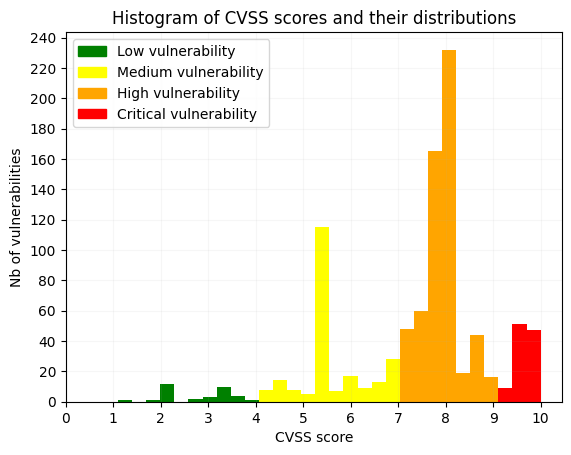

In [103]:
"""
Histogramme des scores CVSS :

Distribution des vulnérabilités
selon leur niveau de gravité (critique, élevée, moyenne)
"""

n, bins, patches = plt.hist(df["CVSS"], bins = 30)
for patch in patches:
    value = patch.get_x()
    if value < 4: patch.set_facecolor('green')
    elif value < 7: patch.set_facecolor('yellow')
    elif value < 9: patch.set_facecolor('orange')
    else: patch.set_facecolor('red')

green_patch = mpatches.Patch(color='green', label='Low vulnerability')
yellow_patch = mpatches.Patch(color='yellow', label='Medium vulnerability')
orange_patch = mpatches.Patch(color='orange', label='High vulnerability')
red_patch = mpatches.Patch(color='red', label='Critical vulnerability')

plt.title("Histogram of CVSS scores and their distributions")
plt.xlabel("CVSS score")
plt.ylabel("Nb of vulnerabilities")
plt.legend(handles=[green_patch, yellow_patch, orange_patch, red_patch])
plt.xticks(np.arange(0, 11, 1))
plt.yticks(np.arange(0, 250, 20))
plt.grid(True, alpha=0.1)



plt.show()

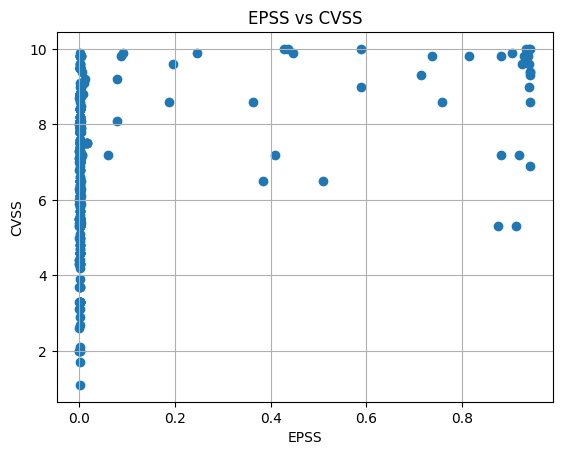

In [104]:
"""
Score EPSS vs score CVSS
"""
# Look only at non null values 
df_not_null = df.drop(['Date', 'Base Severity'], axis=1).dropna(axis=0)
plt.scatter(df_not_null['EPSS'], df_not_null['CVSS'])
plt.xlabel('EPSS')
plt.ylabel('CVSS')
plt.title("EPSS vs CVSS")
plt.grid()
plt.show()

# Even a high CVSS does not mean the intrusion risk is high. But usually, a high intrusion risk means a high CVSS

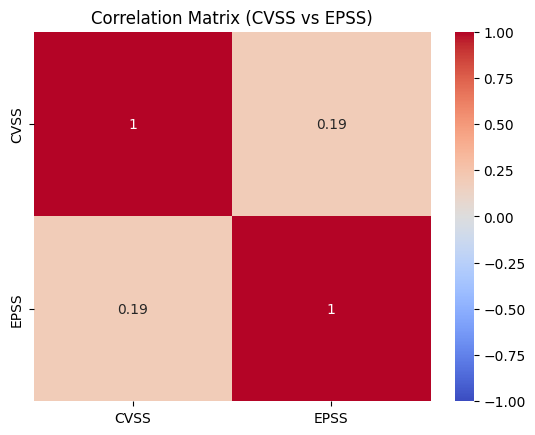

In [105]:
import seaborn as sns 
corr_matrix = df[['CVSS', 'EPSS']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation Matrix (CVSS vs EPSS)')
plt.show()